In [4]:
using Pkg
Pkg.activate(joinpath(dirname(dirname(@__DIR__))))
#Pkg.update()
# If Sunny library is not installed
# using Pkg
# Pkg.add("Sunny")

  Activating project at `/mnt/graphene/home/jalil2/Documents/Projects2026/TDNEGF`


In [5]:
## Main modules 
using TDNEGF
using DifferentialEquations
using LinearAlgebra

println("Number of threads with JUlIA_NUM used in operations is : " , Threads.nthreads() )
println("Number of threads with BLAS used in operations is : " , BLAS.get_num_threads() )

Number of threads with JUlIA_NUM used in operations is : 1
Number of threads with BLAS used in operations is : 1


In [6]:
### Initialize params for electrons using block-based backend
function init_params_blocks(;Nx::Int=3, Ny::Int=2, Nσ::Int=2, N_orb::Int=1,
                     γ::Float64=1.0, γso=0.5 + 0.0im,Nα = 2,
                     N_λ1::Int=49, N_λ2::Int=20, β::Float64=33.0)
    Rλ, zλ = load_poles_square(N_λ1, N_λ2)
    p_model = ModelParamsTDNEGF(Nx = Nx, Ny = Ny, Nσ = Nσ, N_orb = N_orb,
                                Nα = Nα, N_λ1 = N_λ1, N_λ2 = N_λ2)

    H_ab    = build_H_ab(;Nx = p_model.Nx,Ny = p_model.Ny, Nσ = p_model.Nσ, N_orb = p_model.N_orb, γ = γ, γso = γso)
    Σᴸ_nλ   = build_Σᴸ_nλ(Rλ, zλ, p_model.Ny, p_model.Nσ, p_model.N_orb, p_model.N_λ1, p_model.N_λ2; β=β, γ=1.0)
    Σᴳ_nλ   = build_Σᴳ_nλ(Rλ, zλ, p_model.Ny, p_model.Nσ, p_model.N_orb, p_model.N_λ1, p_model.N_λ2; β=β, γ=1.0)
    χ_nλ    = build_χ_nλ(zλ, p_model.Ny, p_model.Nσ, p_model.N_orb, p_model.N_λ1, p_model.N_λ2; β=β, γ=1.0)
    ξ_anR   = build_ξ_an(p_model.Nx, p_model.Ny, p_model.Nσ, p_model.N_orb; xcol = p_model.Nx,y_coup = 1:p_model.Ny)
    ξ_anL   = build_ξ_an(p_model.Nx, p_model.Ny, p_model.Nσ, p_model.N_orb; xcol = 1,y_coup = 1:p_model.Ny)

    left_block  = SelfEnergyBlock(:left,  p_model.Nc, p_model.N_λ1, p_model.N_λ2, Σᴸ_nλ, Σᴳ_nλ, χ_nλ, ξ_anL,  0.0 + 0.0im)
    right_block = SelfEnergyBlock(:right, p_model.Nc, p_model.N_λ1, p_model.N_λ2, Σᴸ_nλ, Σᴳ_nλ, χ_nλ, ξ_anR,  0.0 + 0.0im)
    blocks = [left_block, right_block]

    p_model.H_ab  .= H_ab
    p_model.H0_ab .= H_ab
    p_blocks = ExperimentalBlockRHSParams(p_model.H_ab, blocks, p_model)
    u0 = zeros(ComplexF64, p_blocks.dims_ρ_ab[1]^2 + p_blocks.aux_layout.total_size)

    return (p_model = p_model, p_blocks = p_blocks, u = u0)
end


In [7]:
using Sunny
### Initiallize params for classical spin (Note that sunny.jl package is used)
function init_params_heisenberg_llg(;Nx::Int=2,Ny::Int=2,j_ex::Float64=0.1,a0::Float64=1.0,j_ani::Float64=0.01,Bx::Float64=1e-5)
    latvecs   = lattice_vectors(a0, a0, 4*a0, 90, 90, 90)  # cúbica
    positions = [[0.5, 0.5, 0.0]] 
    # Define the symmtery of the crystal 
    cryst = Crystal(latvecs, positions)
    # Characterizes an effective spin magnetic moment on an atom
    # specification of spi moments
    moments = [1 => Moment(s=1.0, g=1.0)]
    # creates an instance of spin moments
    sys = System(cryst, moments, :dipole; dims=(Nx, Ny, 1)) 
    # Heisenberg interaction 
    set_field!(sys,[Bx,0.0,0.0])
    set_exchange!(sys, j_ex, Bond(1, 1, [1, 0, 0]))  # vecino +x
    set_exchange!(sys, j_ex, Bond(1, 1, [0, 1, 0]))  # vecino +y
    set_onsite_coupling!(sys, S ->  -j_ani*S[3]^2, 1)
   # set_onsite_coupling!(sys, S -> -Bx*S[1], 1)
    sys = to_inhomogeneous(sys)
    remove_periodicity!(sys, (true, true, true)) 
    
    ### Initial state
    if j_ex >= 0.0 #(+ is antiferro)
        for I in eachindex(sys.dipoles)
            i,j=ij_from_linear(I,Ny)
            sys.dipoles[I] = Sunny.SVector(0.0, 0.0, (-1)^(i+j) )  
        end
    else  #(- is ferro)
        for I in eachindex(sys.dipoles)
            sys.dipoles[I] = Sunny.SVector(0.0, 0.0, 1.0)  ### AFM configuration
        end
    end
    return sys
end
@inline linear_index(i::Int, j::Int, Ny::Int) = (i - 1) * Ny + j
@inline function ij_from_linear(l::Int, Ny::Int)
    i = (l - 1) ÷ Ny + 1
    j = (l - 1) % Ny + 1
    return i, j
end
### Update the classical Hamiltonian
function update_H_s!(Nx::Int,Ny::Int,sys::System{0},σx_i::Array{Float64, 2}, j_sd::Float64,B0::Vector{Float64}=[0.0, 0.0, 0.0] )
    #B0 = sys.extfield[1,1,1,1] #### Take the global field
    @inbounds for i in 1:Nx for j in 1:Ny
        idx = linear_index(i,j,Ny) ### include the spin degree of freedom
        sden = -σx_i[idx,:]*j_sd
        set_field_at!(sys, sden .+ B0 ,(i , j, 1, 1)) 
        #println(i,j)
    end end
    return nothing 
end
# # sys = init_params_heisenberg_llg(j_ex=0.1)
# sys = init_params_heisenberg_llg(Nx = 2 ,Ny = 2, j_ex = 0.1)
# sys.dipoles

update_H_s! (generic function with 2 methods)

In [8]:
smooth_switch_on(t::Float64;ti=10.0) =t < 0.0 ? 0.0 : (t < ti ? sin((pi/2)*t/ti)^2 : 1) ;

smooth_pulse(t::Float64; ti::Float64=10.0, Δ::Float64=100.0) =
    t < 0.0 ? 0.0 :
    (t < ti ? sin((pi/2)*t/ti)^2 :
    (t < Δ ? 1.0 :
    (t < Δ + ti ? cos((pi/2)*(t-Δ)/ti)^2 : 0.0)))

smooth_pulse (generic function with 1 method)

In [34]:
#p = init_params()

In [35]:
#p.N_sites

In [62]:
function spin_dynamics_and_electrons_evolution(t_0::Float64, Δt::Float64 ,t_end::Float64;j_sd::Float64 = 0.1,
        j_ex::Float64 = 0.1,j_ani::Float64=0.1,Bx::Float64=0.0,u0=nothing,m0=nothing, p0 = nothing)
    println("Join the Main function")
    pstate = p0 === nothing ? init_params_blocks() : p0
    p_model = pstate.p_model
    p_blocks = pstate.p_blocks
    u = u0 === nothing ? copy(pstate.u) : u0

    m0 === nothing ? sys = init_params_heisenberg_llg(Nx = p_model.Nx ,Ny = p_model.Ny, j_ex = j_ex, j_ani = j_ani, Bx=Bx) : sys = m0

    # Main evolution now uses the block RHS and pointer_blocks observables.
    prob = ODEProblem(eom_tdnegf_blocks!, u, (t_0,t_end), p_blocks)
    intg = init(prob,Vern7(),dt = Δt, save_everystep=false,adaptive=true,dense=false)
    integ = Langevin(Δt ; damping=0.5, kT=0.0)
    println("The integrator has been set")

    N_steps = Int(round((t_end - t_0)/Δt))
    obs = ObservablesTDNEGF(p_model; N_tmax=N_steps , N_leads = length(p_blocks.blocks))
    site_ranges_couple = [get_sub(i, p_model.N_loc) for i in 1:p_model.N_sites]

    @time for i in 1:N_steps
        obs.idx = i
        DifferentialEquations.step!(intg, Δt, true)
        Sunny.step!(sys,integ)

        println("time: ", round(intg.t, digits=2))
        flush(stdout)

        dv = pointer_blocks(intg.u, p_blocks.dims_ρ_ab, p_blocks.aux_layout)
        ρ  = ρ_eq(0.0, 33.0, p_model.H_ab, p_model.N_λ2,p_model.Nx,p_model.Ny,p_model.Nσ,p_model.N_orb)

        obs.t[i] = intg.t
        obs_n_i!(dv, p_model, obs)
        obs_σ_i!(dv, p_model, obs)
        obs_Ixα!(dv, p_blocks, obs)
        obs_s_i!(sys.dipoles[:,:,1,1], p_model, obs)
        obs_σ_i_eq!(ρ, p_model, obs)

        update_H_s!(p_model.Nx,p_model.Ny,sys,obs.σx_i[:,:,i], j_sd)
        update_H_e!(p_model, site_ranges_couple, sys.dipoles[:,:,1,1], j_sd)
        Δ_left = smooth_pulse(intg.t .-100.0;ti=10.0,Δ=1000.0)*1.0 + 0im
        p_blocks.blocks[1] = SelfEnergyBlock(p_blocks.blocks[1].name, p_blocks.blocks[1].Nc,
            p_blocks.blocks[1].N_λ1, p_blocks.blocks[1].N_λ2, p_blocks.blocks[1].ΣL_nλ,
            p_blocks.blocks[1].ΣG_nλ, p_blocks.blocks[1].χ_nλ, p_blocks.blocks[1].ξ_an, Δ_left)
        p_blocks.blocks[2] = SelfEnergyBlock(p_blocks.blocks[2].name, p_blocks.blocks[2].Nc,
            p_blocks.blocks[2].N_λ1, p_blocks.blocks[2].N_λ2, p_blocks.blocks[2].ΣL_nλ,
            p_blocks.blocks[2].ΣG_nλ, p_blocks.blocks[2].χ_nλ, p_blocks.blocks[2].ξ_an, 0.0 + 0im)
    end

    return  obs, intg.u, sys, (p_model = p_model, p_blocks = p_blocks, u = intg.u)
end


spin_dynamics_and_electrons_evolution (generic function with 1 method)

In [63]:
obs,u0,m0,p0 = spin_dynamics_and_electrons_evolution(0.0,0.1,120.0; j_ex = -0.05,j_sd = 0.1) #(+ is antiferro /- is ferro)
obs1,u01,m01,p01 = spin_dynamics_and_electrons_evolution(obs.t[end],0.1,200.0; j_ex = -0.05,j_sd = 0.1,u0,m0,p0)

Join the Main function
The integrator has been set
time: 0.1
time: 0.2
time: 0.3
time: 0.4
time: 0.5
time: 0.6
time: 0.7
time: 0.8
time: 0.9
time: 1.0
time: 1.1
time: 1.2
time: 1.3
time: 1.4
time: 1.5
time: 1.6
time: 1.7
time: 1.8
time: 1.9
time: 2.0
time: 2.1
time: 2.2
time: 2.3
time: 2.4
time: 2.5
time: 2.6
time: 2.7
time: 2.8
time: 2.9
time: 3.0
time: 3.1
time: 3.2
time: 3.3
time: 3.4
time: 3.5
time: 3.6
time: 3.7
time: 3.8
time: 3.9
time: 4.0
time: 4.1
time: 4.2
time: 4.3
time: 4.4
time: 4.5
time: 4.6
time: 4.7
time: 4.8
time: 4.9
time: 5.0
time: 5.1
time: 5.2
time: 5.3
time: 5.4
time: 5.5
time: 5.6
time: 5.7
time: 5.8
time: 5.9
time: 6.0
time: 6.1
time: 6.2
time: 6.3
time: 6.4
time: 6.5
time: 6.6
time: 6.7
time: 6.8
time: 6.9
time: 7.0
time: 7.1
time: 7.2
time: 7.3
time: 7.4
time: 7.5
time: 7.6
time: 7.7
time: 7.8
time: 7.9
time: 8.0
time: 8.1
time: 8.2
time: 8.3
time: 8.4
time: 8.5
time: 8.6
time: 8.7
time: 8.8
time: 8.9
time: 9.0
time: 9.1
time: 9.2
time: 9.3
time: 9.4
time: 9.5

(ObservablesTDNEGF{Float64}([120.09999999999745, 120.19999999999744, 120.29999999999744, 120.39999999999743, 120.49999999999743, 120.59999999999742, 120.69999999999742, 120.79999999999741, 120.8999999999974, 120.9999999999974  …  199.09999999999297, 199.19999999999297, 199.29999999999296, 199.39999999999296, 199.49999999999295, 199.59999999999295, 199.69999999999294, 199.79999999999293, 199.89999999999293, 199.99999999999292], [1.16587454658127 1.1660267472165788 … 1.1732381632987359 1.1732429329497893; 1.1710872453679022 1.1711824460495404 … 1.1786356984517545 1.1786407317467051; … ; 1.052332037138339 1.0525065498401438 … 1.0744139359514384 1.0744187698936984; 1.0581046078230072 1.0581942053529323 … 1.08065523013193 1.0806604478452715], [0.03014811738127374 0.015007518934879723 0.024086895537425046; 0.014049869012266349 0.0007766672037248019 0.03228941535051222; … ; -0.03736283123396589 0.02957826707094722 -0.007278060524878116; -0.04689061580506497 -0.013115540184585727 -0.0041653181

In [51]:
#typeof(obs_AFM.sx_i)

In [52]:
#size(obs_AFM.sx_i)

In [53]:
using PyPlot
plt.rc("axes", linewidth=1)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text
fs=25

25

In [110]:
### Lets plot the AFM against the FM configuration 
# Calculation of the average magnetization for FM configuration
function avg_M(dip::Array{Float64, 3},Nx::Int,Ny::Int)
    size_t   = size(dip)[3]
    size_sys = Nx*Ny#size(dip)[1]
    M_t      = zeros(Float64,3,size_t)
    for t_idx in 1:size_t
        for i in 1:size_sys
            for x in 1:3
                M_t[x,t_idx] +=  dip[i ,x,t_idx]
            end
        end
    end
    return M_t/size_sys
end
# Calculation of the average Neel Vector for AFM configuration
function avg_N(dip::Array{Float64, 3},Nx::Int,Ny::Int)
                
    size_t   = size(dip)[3]
    size_sys = Nx*Ny
    N_t      = zeros(Float64,3,size_t)
    for t_idx in 1:size_t
        for i in 1:size_sys
            i_x,j_y = ij_from_linear(i,Ny)
            for x in 1:3
                N_t[x,t_idx] +=  dip[i ,x,t_idx]*(-1)^(i_x+j_y)
            end
        end
    end
    return N_t/size_sys

end

avg_N (generic function with 1 method)

In [85]:
#obs_AFM.sx_i

In [86]:
#N = avg_N(obs_AFM.sx_i,2,2)

In [11]:
# plt.plot(obs_AFM.t,N[1,:])
# plt.plot(obs_AFM.t,N[2,:])
# plt.plot(obs_AFM.t,N[3,:])

In [12]:
# fig,axs =  plt.subplots(2,2)

# axs[1,1].set_ylabel(raw"$\mathrm{N^{\alpha}}$", fontsize = fs)
# axs.plot(obs_FM.t,obs_AFM.sx_i[1,1,:],color = "red")
# #axs.plot(obs_FM.t,obs_AFM.sx_i[2,1,:],color = "blue")

# axs[1,2].set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)


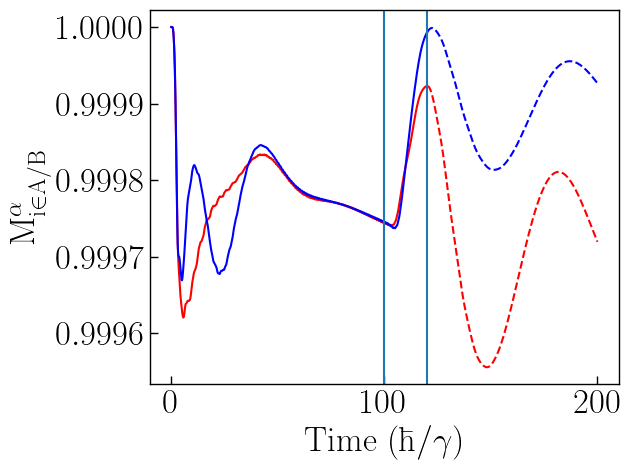

In [65]:

fig,axs =  plt.subplots(1,1)
site = 3
sites = range(1,2)
# for site in sites
#    # obs2.t .+obs.t[end]
#     axs.plot(obs.t,obs.sx_i[site,1,:])#,alpha =1-0.2*i ) ### Charge bound current
#     #axs.plot(obs.t,obs.sx_i[site,2,:],label= raw"$\alpha=y$ ")
#     #axs.plot(obs.t,obs.sx_i[site,3,:],label= "site=$(site)")
#    # axs.plot(obs2.t .+obs.t[end],obs2.sx_i[site,3,:],label= raw"$\alpha=z$ ")
# end
# axs.plot(obs_AFM.t,obs_AFM.sx_i[1,1,:],color = "red")
# axs.plot(obs_AFM.t,obs_AFM.sx_i[2,1,:],color = "blue")

# axs.plot(obs_AFM.t,obs_AFM.sx_i[3,1,:],color = "red")
# axs.plot(obs_AFM.t,obs_AFM.sx_i[4,1,:],color = "blue")

# axs.plot(obs.t,obs.sx_i[1,2,:],color = "red",ls = ":")
# axs.plot(obs.t,obs.sx_i[2,2,:],color = "blue",ls = ":")

axs.plot(obs.t,obs.sx_i[1,3,:],color = "red",ls = "-")
axs.plot(obs.t,obs.sx_i[2,3,:],color = "blue",ls = "-")

axs.plot(obs1.t,obs1.sx_i[1,3,:],color = "red",ls = "--")
axs.plot(obs1.t,obs1.sx_i[2,3,:],color = "blue",ls = "--")

#axs.plot(obs_AFM.t,obs_AFM.sx_i[4,3,:],color = "red",ls = "--")

# axs.plot(obs.t,obs.sx_i[3,3,:],color = "red",ls = "-")
# axs.plot(obs.t,obs.sx_i[4,3,:],color = "blue",ls = "-")
# line1 = plt.plot([0, 1], [0, 1], color="red",ls="-")[1]
# line2 = plt.plot([0, 1], [1, 0], color="blue",ls="-")[1]
# line3 = plt.plot([0, 1], [1, 0], color="black",ls="-")[1]
# line4 = plt.plot([0, 1], [1, 0], color="black",ls="--")[1]
# lg2 = axs.legend([line1, line2, line3, line4], [raw"$\rm{i \in A}$", raw"$\rm{i \in B}$", raw"$\rm{\alpha=x}$", raw"$\rm{\alpha=z}$"]
#                 ,frameon = false, fontsize = fs-10, loc= (0.05,  0.9),ncol =4,columnspacing=0.5)
# axs.add_artist(lg2)

axs.set_ylabel(raw"$\mathrm{M^{\alpha}_{i \in A/B}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))

axs.axvline(100)
axs.axvline(120)
# axs.axvline(50)
# axs.axvline(150)
#plt.xlim(0,150)
#axs.text(x=0.08, y=0.1, s = raw"$\mathrm{Vb}$",fontsize=fs-2,ha="center", transform=axs.transAxes,color="gray")
#plt.xlim(0,500)
#plt.ylim(-1.5,1.3)
plt.tight_layout()

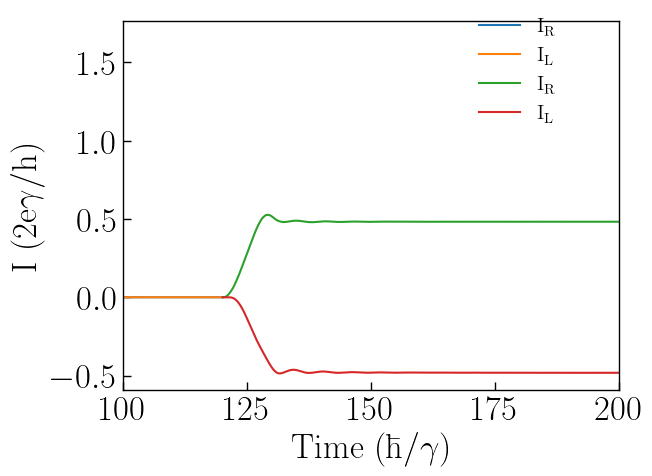

PyObject <matplotlib.legend.Legend object at 0x7f1f15366900>

In [58]:
fig,axs = plt.subplots(1,1)
axs.plot(obs.t,obs.Iα[1,:], label = raw"$\mathrm{I_R}$")  ### Units of 2e/h 
axs.plot(obs.t,obs.Iα[2,:], label = raw"$\mathrm{I_L}$")
#axs.plot(obs.t,obs.Iα[2,:]*pi .+ obs.Iα[1,:]*pi , label = raw"$\mathrm{I_T}$")


# axs.plot(obs2.t .+obs.t[end],obs2.Iα[1,:]*pi, label = raw"$\mathrm{I_R}$")  ### Units of 2e/h 
# axs.plot(obs2.t .+obs.t[end],obs2.Iα[2,:]*pi, label = raw"$\mathrm{I_L}$")
#axs.plot(obs2.t .+obs.t[end],obs2.Iα[2,:]*pi .+ obs.Iα[1,:]*pi , label = raw"$\mathrm{I_T}$")
#axs.axhline(1)
#axs.axhline(-0.1)


axs.plot(obs1.t,obs1.Iα[1,:], label = raw"$\mathrm{I_R}$")  ### Units of 2e/h 
axs.plot(obs1.t, obs1.Iα[2,:], label = raw"$\mathrm{I_L}$")

axs.set_ylabel(L"$\mathrm{I\ (2e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.xlim(100,200)
#plt.ylim(-0.001,0.001)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.7))

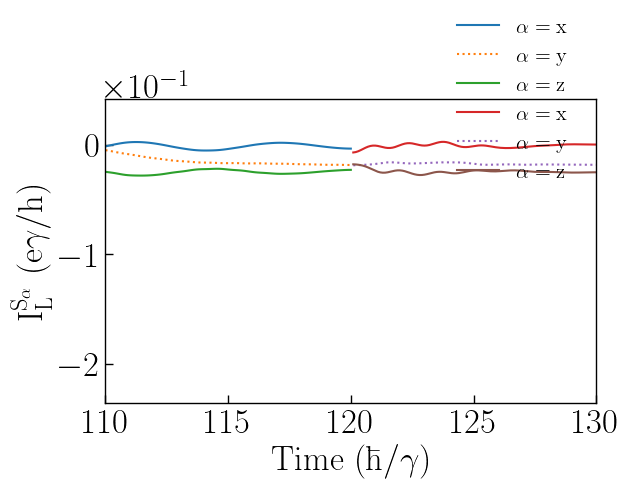

In [43]:
fig,axs = plt.subplots(1,1)
axs.plot(obs.t,obs.Iαx[1,1,:], label = raw"$\mathrm{\alpha = x}$")
axs.plot(obs.t,obs.Iαx[1,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
axs.plot(obs.t,obs.Iαx[1,3,:], label = raw"$\mathrm{\alpha = z}$")

#axs.plot(obs_AFM.t,obs_AFM.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")

# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,1,:], label = raw"$\mathrm{\alpha = x}$")
# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,3,:], label = raw"$\mathrm{\alpha = z}$")


axs.plot(obs1.t,obs1.Iαx[1,1,:], label = raw"$\mathrm{\alpha = x}$")
axs.plot(obs1.t,obs1.Iαx[1,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
axs.plot(obs1.t,obs1.Iαx[1,3,:], label = raw"$\mathrm{\alpha = z}$")


#axs.plot(obs.t,obs.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")

#axs.plot(obs.t,obs.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
axs.set_ylabel(raw"$\mathrm{I^{S_{\alpha}}_L\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.axhline(0.08)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.7))
plt.xlim(110,130)
#axs.set_ylim(-2e-1,2e-1)
#axs.set_ylim(-2e-5,2e-5)
#plt.xlim(0,200)
plt.tight_layout()

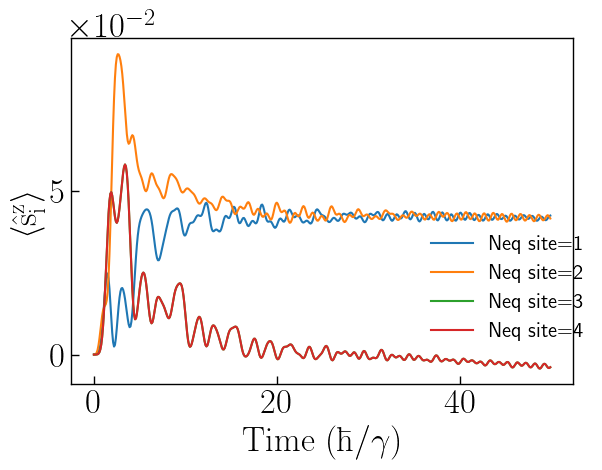

In [160]:


fig,axs =  plt.subplots(1,1)
site = 1
sites = 1:4#2:2:12#range(1,4)
for site in sites
    
    #axs.plot(obs2.t,obs2.σx_i[site,1,:],label= "site=$(site)")#,alpha =1-0.2*i ) ### Charge bound current
    #axs.plot(obs.t,obs.σx_i[site,2,:],label= raw"$\alpha=y$ ")
    axs.plot(obs.t,obs.σx_i[site,3,:],label= "Neq site=$(site)")
    #axs.plot(obs.t,obs.σx_i_eq[site,3,:],label= "Eq site=$(site)")
    #axs.plot(obs2.t .+obs.t[end],obs2.σx_i[site,3,:],label= raw"$\alpha=z$ ")
end

axs.set_ylabel(raw"$\langle\mathrm{\hat{s}^{z}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#plt.xlim(200,300)
plt.tight_layout()

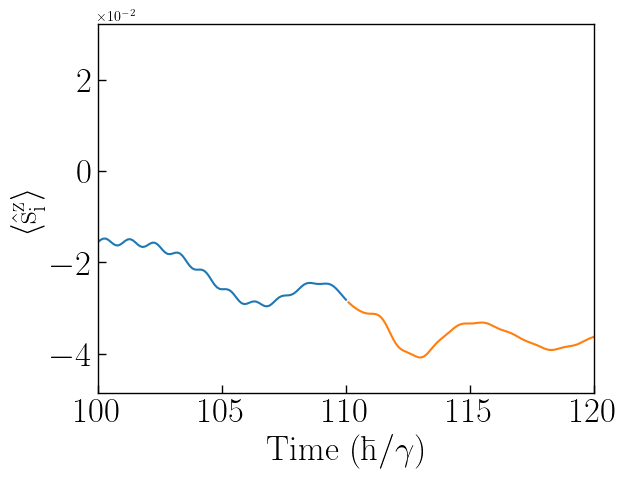

PyObject Text(0.5, 44.59250034592501, '$\\mathrm{Time\\ (\\hbar/\\gamma)}$')

In [25]:

fig,axs =  plt.subplots(1,1)

axs.plot(obs.t,obs.σx_i[3,3,:],label= "Neq site=1")
axs.plot(obs1.t  ,obs1.σx_i[3,3,:],label= "Neq site=1")

axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
#plt.ylim(-0.01,0.01)
plt.xlim(100,120)

axs.set_ylabel(raw"$\langle\mathrm{\hat{s}^{z}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)